#  PENGUJIAN DAN EVALUASI MODEL DEEP LEARNING KLASIFIKASI CITRA MAKANAN
##  Studi Kasus: Klasifikasi Makanan & Estimasi Kandungan Gizi (ResNet-50 vs EfficientNet-B0)
---
**Dokumen Pengujian Google Colab (Revisi Ujian Hasil)**
- **Metode:** Convolutional Neural Network (CNN) - Transfer Learning (ResNet-50 vs EfficientNet-B0)
- **Estimasi Gizi:** Atwater General Factor System (Karbohidrat, Protein, Lemak, Serat, Sodium)
- **Dataset:** 4 Kelas Makanan (Bread, Noodles-Pasta, Seafood, nasi-goreng)
- **Metrik Evaluasi:** Accuracy, Precision, Recall, F1-Score, Confusion Matrix, & Loss/Accuracy Curves


###  Langkah 1: Persiapan Environment & GPU
Memastikan ketersediaan akselerator GPU (CUDA) untuk mempercepat proses pelatihan dan pengujian model.

In [4]:
# Periksa ketersediaan GPU di Google Colab
!nvidia-smi

import os
import time
import json
import copy
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[INFO] PyTorch Version: {torch.__version__}")
print(f"[INFO] Menggunakan Komputasi Device: {DEVICE}")

zsh:1: command not found: nvidia-smi
[] PyTorch Version: 2.14.0
[] Menggunakan Komputasi Device: cpu


###  Langkah 2: Menyiapkan Dataset & Google Drive (Opsional)
Dataset dapat diunggah langsung ke Colab atau di-mount dari Google Drive.
Struktur folder yang diharapkan:
```
data/
  ├── train/ (Bread, Noodles-Pasta, Seafood, nasi-goreng)
  └── val/   (Bread, Noodles-Pasta, Seafood, nasi-goreng)
```

=== Distribusi Jumlah Citra per Kelas ===


,Data Latih (Train),Data Uji/Validasi (Val)
Bread,294,74
Noodles-Pasta,118,29
Seafood,242,61
nasi-goreng,77,20


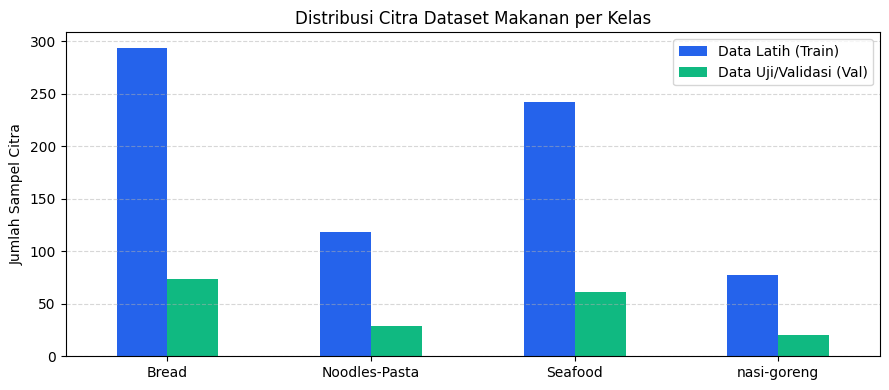

In [5]:
# Opsi: Hubungkan ke Google Drive jika dataset disimpan di Drive
# from google.colab import drive
# drive.mount('/content/drive')

# Jika mengunggah zip dataset secara langsung:
# !unzip -q dataset_makanan.zip -d ./

TRAIN_DIR = 'data/train'
VAL_DIR = 'data/val'

def inspect_dataset(dir_path):
    if not os.path.exists(dir_path):
        print(f"Direktori '{dir_path}' belum ditemukan. Silakan upload dataset.")
        return {}
    classes = sorted([d for d in os.listdir(dir_path) if os.path.isdir(os.path.join(dir_path, d)) and not d.startswith('.')])
    counts = {}
    for c in classes:
        cdir = os.path.join(dir_path, c)
        files = [f for f in os.listdir(cdir) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.webp'))]
        counts[c] = len(files)
    return counts

train_counts = inspect_dataset(TRAIN_DIR)
val_counts = inspect_dataset(VAL_DIR)

df_dist = pd.DataFrame({'Data Latih (Train)': train_counts, 'Data Uji/Validasi (Val)': val_counts})
print("=== Distribusi Jumlah Citra per Kelas ===")
display(df_dist)

# Visualisasi Distribusi
if not df_dist.empty:
    df_dist.plot(kind='bar', figsize=(9, 4), color=['#2563eb', '#10b981'])
    plt.title('Distribusi Citra Dataset Makanan per Kelas')
    plt.ylabel('Jumlah Sampel Citra')
    plt.xticks(rotation=0)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

###  Langkah 3: Basis Data Kandungan Gizi & Sistem Atwater
Mendefinisikan kriteria gizi dan kandungan nutrisi per porsi terstandarisasi untuk setiap kelas makanan.

In [6]:
NUTRITION_DATABASE = {
    'Bread': {
        'calories': 265.0,
        'portion_desc': '2 lembar (100g)',
        'carbs': 49.0,
        'protein': 9.0,
        'fat': 3.2,
        'fiber': 2.7,
        'sodium': 490.0,
        'health_score': 65,
        'criteria': 'Sumber Karbohidrat Sedang',
        'recommendation': 'Baik untuk energi harian, kombinasikan dengan protein telur/daging tanpa lemak.'
    },
    'nasi-goreng': {
        'calories': 520.0,
        'portion_desc': '1 piring sedang (250g)',
        'carbs': 68.0,
        'protein': 14.0,
        'fat': 22.0,
        'fiber': 2.1,
        'sodium': 820.0,
        'health_score': 48,
        'criteria': 'Tinggi Kalori & Lemak Olahan',
        'recommendation': 'Batasi porsi dan hindari konsumsi berlebih pada malam hari.'
    },
    'Noodles-Pasta': {
        'calories': 380.0,
        'portion_desc': '1 mangkuk (200g)',
        'carbs': 64.0,
        'protein': 12.0,
        'fat': 8.5,
        'fiber': 3.2,
        'sodium': 580.0,
        'health_score': 58,
        'criteria': 'Padat Energi & Karbohidrat Olahan',
        'recommendation': 'Sangat disarankan menambah sayuran segar untuk mencukupi serat pangan.'
    },
    'Seafood': {
        'calories': 210.0,
        'portion_desc': '1 porsi (150g)',
        'carbs': 4.5,
        'protein': 32.0,
        'fat': 6.0,
        'fiber': 0.5,
        'sodium': 320.0,
        'health_score': 85,
        'criteria': 'Tinggi Protein & Rendah Lemak Jenuh',
        'recommendation': 'Pilihan terbaik untuk pemenuhan asam amino esensial dan program diet sehat.'
    }
}

df_nut = pd.DataFrame(NUTRITION_DATABASE).T
print("=== Tabel Komposisi Kandungan Gizi Terstandarisasi ===")
display(df_nut[['calories', 'carbs', 'protein', 'fat', 'fiber', 'sodium', 'health_score', 'criteria']])

=== Tabel Komposisi Kandungan Gizi Terstandarisasi ===


,calories,carbs,protein,fat,fiber,sodium,health_score,criteria
Bread,265.0,49.0,9.0,3.2,2.7,490.0,65,Sumber Karbohidrat Sedang
nasi-goreng,520.0,68.0,14.0,22.0,2.1,820.0,48,Tinggi Kalori & Lemak Olahan
Noodles-Pasta,380.0,64.0,12.0,8.5,3.2,580.0,58,Padat Energi & Karbohidrat Olahan
Seafood,210.0,4.5,32.0,6.0,0.5,320.0,85,Tinggi Protein & Rendah Lemak Jenuh


###  Langkah 4: Pipeline Data Loading & Augmentasi Citra
Menerapkan teknik augmentasi (Horizontal Flip, Random Rotation, Color Jitter, Random Resized Crop) untuk mencegah overfitting.

In [13]:
class CustomFoodDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.files = []
        self.labels = []
        self.transform = transform
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d)) and not d.startswith('.')])
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}
        
        valid_exts = ('.jpg', '.jpeg', '.png', '.webp')
        for c in self.classes:
            cdir = os.path.join(root_dir, c)
            for f in os.listdir(cdir):
                if f.lower().endswith(valid_exts) and not f.startswith('.'):
                    self.files.append(os.path.join(cdir, f))
                    self.labels.append(self.class_to_idx[c])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = Image.open(self.files[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

INPUT_SIZE = 224
BATCH_SIZE = 16

train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.85, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CustomFoodDataset(TRAIN_DIR, transform=train_transform)
val_dataset = CustomFoodDataset(VAL_DIR, transform=val_transform)
CLASSES = train_dataset.classes

# windoes
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# macos
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"[INFO] Kelas Makanan ({len(CLASSES)}): {CLASSES}")
print(f"[INFO] Data Pelatihan: {len(train_dataset)} citra ({len(train_loader)} batches)")
print(f"[INFO] Data Validasi: {len(val_dataset)} citra ({len(val_loader)} batches)")

[INFO] Kelas Makanan (4): ['Bread', 'Noodles-Pasta', 'Seafood', 'nasi-goreng']
[INFO] Data Pelatihan: 731 citra (46 batches)
[INFO] Data Validasi: 184 citra (12 batches)


###  Langkah 5: Definisi Model Arsitektur (ResNet-50 vs EfficientNet-B0)
Menggunakan Transfer Learning berbasis arsitektur deep learning terstandarisasi.

In [14]:
def build_model(arch_name, num_classes):
    if arch_name == 'resnet50':
        try:
            weights = models.ResNet50_Weights.DEFAULT
            model = models.resnet50(weights=weights)
        except Exception:
            model = models.resnet50(pretrained=True)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, num_classes)
    elif arch_name == 'efficientnet_b0':
        try:
            weights = models.EfficientNet_B0_Weights.DEFAULT
            model = models.efficientnet_b0(weights=weights)
        except Exception:
            model = models.efficientnet_b0(pretrained=True)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_classes)
    else:
        raise ValueError(f"Arsitektur '{arch_name}' tidak dikenal.")
    return model.to(DEVICE)

print("[INFO] Fungsi build_model berhasil dimuat.")

[INFO] Fungsi build_model berhasil dimuat.


###  Langkah 6: Engine Pelatihan & Evaluasi Terstandarisasi
Fungsi training dengan pencatatan riwayat Loss & Akurasi, Learning Rate Scheduler, serta Confusion Matrix.

In [15]:
def train_and_evaluate(model, arch_name, train_loader, val_loader, epochs=10, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': [],
        'val_p': [], 'val_r': [], 'val_f1': []
    }
    
    best_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    best_y_true = []
    best_y_pred = []
    
    start_time = time.time()
    print(f"\n{'='*20} MEMULAI TRAINING: {arch_name.upper()} ({epochs} EPOCHS) {'='*20}")
    
    for epoch in range(1, epochs + 1):
        # Train
        model.train()
        t_loss, t_correct, t_total = 0.0, 0, 0
        for imgs, labs in train_loader:
            imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labs)
            loss.backward()
            optimizer.step()
            
            t_loss += loss.item() * imgs.size(0)
            preds = torch.argmax(out, dim=1)
            t_correct += (preds == labs).sum().item()
            t_total += labs.size(0)
            
        ep_t_loss = t_loss / t_total
        ep_t_acc = t_correct / t_total
        
        # Val
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        y_true_ep, y_pred_ep = [], []
        with torch.no_grad():
            for imgs, labs in val_loader:
                imgs, labs = imgs.to(DEVICE), labs.to(DEVICE)
                out = model(imgs)
                loss = criterion(out, labs)
                v_loss += loss.item() * imgs.size(0)
                preds = torch.argmax(out, dim=1)
                v_correct += (preds == labs).sum().item()
                v_total += labs.size(0)
                y_true_ep.extend(labs.cpu().numpy())
                y_pred_ep.extend(preds.cpu().numpy())
                
        ep_v_loss = v_loss / v_total
        ep_v_acc = v_correct / v_total
        scheduler.step(ep_v_loss)
        
        p_mac, r_mac, f1_mac, _ = precision_recall_fscore_support(y_true_ep, y_pred_ep, average='macro', zero_division=0)
        
        history['train_loss'].append(ep_t_loss)
        history['train_acc'].append(ep_t_acc)
        history['val_loss'].append(ep_v_loss)
        history['val_acc'].append(ep_v_acc)
        history['val_p'].append(p_mac)
        history['val_r'].append(r_mac)
        history['val_f1'].append(f1_mac)
        
        print(f"Epoch [{epoch:02d}/{epochs}] -> Train Loss: {ep_t_loss:.4f} | Val Loss: {ep_v_loss:.4f} | Train Acc: {ep_t_acc*100:.2f}% | Val Acc: {ep_v_acc*100:.2f}% | F1: {f1_mac:.4f}")
        
        if ep_v_acc > best_acc:
            best_acc = ep_v_acc
            best_weights = copy.deepcopy(model.state_dict())
            best_y_true = y_true_ep
            best_y_pred = y_pred_ep
            
    dur = time.time() - start_time
    print(f"[INFO] Selesai dalam {dur/60:.2f} menit. Akurasi Terbaik: {best_acc*100:.2f}%")
    
    model.load_state_dict(best_weights)
    return model, history, best_acc, best_y_true, best_y_pred

###  Langkah 7: Pelatihan Eksperimen 1 — ResNet-50
Melatih model ResNet-50 dan mencatat kurva serta metrik kinerja.

In [17]:
EPOCHS = 10
model_resnet = build_model('resnet50', len(CLASSES))
model_resnet, hist_resnet, best_acc_resnet, resnet_y_true, resnet_y_pred = train_and_evaluate(
    model_resnet, 'resnet50', train_loader, val_loader, epochs=EPOCHS, lr=1e-4
)

# Simpan bobot model terbaik
torch.save({'model_state': model_resnet.state_dict(), 'classes': CLASSES, 'arch': 'resnet50'}, 'best_resnetgooglecollap50.pth')


==================== MEMULAI TRAINING: RESNET50 (10 EPOCHS) ====================
Epoch [01/10] -> Train Loss: 0.8729 | Val Loss: 0.2290 | Train Acc: 72.50% | Val Acc: 95.11% | F1: 0.9374


KeyboardInterrupt: 

###  Langkah 8: Pelatihan Eksperimen 2 — EfficientNet-B0
Melatih model EfficientNet-B0 dengan dataset dan konfigurasi hiperparameter yang identik untuk perbandingan adil (*fair comparison*).

In [ ]:
model_effnet = build_model('efficientnet_b0', len(CLASSES))
model_effnet, hist_effnet, best_acc_effnet, effnet_y_true, effnet_y_pred = train_and_evaluate(
    model_effnet, 'efficientnet_b0', train_loader, val_loader, epochs=EPOCHS, lr=1e-4
)

# Simpan bobot model terbaik
torch.save({'model_state': model_effnet.state_dict(), 'classes': CLASSES, 'arch': 'efficientnet_b0'}, 'best_efficientnet_b0.pth')

###  Langkah 9: Visualisasi Komparasi Kurva Pembelajaran (Learning Curves)
Membandingkan dinamika konvergensi Loss dan Akurasi antara ResNet-50 dan EfficientNet-B0.

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, EPOCHS + 1)

# Perbandingan Kurva Loss Validasi
ax1.plot(epochs_range, hist_resnet['val_loss'], label='ResNet-50 (Val Loss)', color='#2563eb', marker='o', linewidth=2)
ax1.plot(epochs_range, hist_effnet['val_loss'], label='EfficientNet-B0 (Val Loss)', color='#10b981', marker='s', linewidth=2)
ax1.set_title('Perbandingan Validasi Loss per Epoch', fontsize=12, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Perbandingan Kurva Akurasi Validasi
ax2.plot(epochs_range, [a * 100 for a in hist_resnet['val_acc']], label='ResNet-50 (Val Acc)', color='#2563eb', marker='o', linewidth=2)
ax2.plot(epochs_range, [a * 100 for a in hist_effnet['val_acc']], label='EfficientNet-B0 (Val Acc)', color='#10b981', marker='s', linewidth=2)
ax2.set_title('Perbandingan Validasi Akurasi (%) per Epoch', fontsize=12, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Akurasi (%)')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.savefig('learning_curves_comparison.png', dpi=300)
plt.show()

###  Langkah 10: Evaluasi Mendalam (Confusion Matrix & Classification Report)
Menganalisis matriks kebingungan dan metrik detail per kelas makanan.

In [ ]:
# Confusion Matrix ResNet-50 vs EfficientNet-B0
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

cm_resnet = confusion_matrix(resnet_y_true, resnet_y_pred)
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax1)
ax1.set_title(f'Confusion Matrix: ResNet-50\n(Akurasi: {best_acc_resnet*100:.2f}%)')
ax1.set_xlabel('Prediksi Model')
ax1.set_ylabel('Kelas Aktual')

cm_effnet = confusion_matrix(effnet_y_true, effnet_y_pred)
sns.heatmap(cm_effnet, annot=True, fmt='d', cmap='Greens', xticklabels=CLASSES, yticklabels=CLASSES, ax=ax2)
ax2.set_title(f'Confusion Matrix: EfficientNet-B0\n(Akurasi: {best_acc_effnet*100:.2f}%)')
ax2.set_xlabel('Prediksi Model')
ax2.set_ylabel('Kelas Aktual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300)
plt.show()

print("=== CLASSIFICATION REPORT: RESNET-50 ===")
print(classification_report(resnet_y_true, resnet_y_pred, target_names=CLASSES, digits=4))

print("\n=== CLASSIFICATION REPORT: EFFICIENTNET-B0 ===")
print(classification_report(effnet_y_true, effnet_y_pred, target_names=CLASSES, digits=4))

###  Langkah 11: Tabel Rekapitulasi Komparasi Kinerja Arsitektur
Menampilkan tabel komparasi formal untuk kebutuhan Bab 4 (Hasil dan Pembahasan) Laporan Skripsi.

In [ ]:
p_res, r_res, f1_res, _ = precision_recall_fscore_support(resnet_y_true, resnet_y_pred, average='macro')
p_eff, r_eff, f1_eff, _ = precision_recall_fscore_support(effnet_y_true, effnet_y_pred, average='macro')

summary_data = {
    'Arsitektur Model': ['ResNet-50', 'EfficientNet-B0'],
    'Akurasi (%)': [f"{best_acc_resnet*100:.2f}%", f"{best_acc_effnet*100:.2f}%"],
    'Precision (Macro)': [f"{p_res*100:.2f}%", f"{p_eff*100:.2f}%"],
    'Recall (Macro)': [f"{r_res*100:.2f}%", f"{r_eff*100:.2f}%"],
    'F1-Score (Macro)': [f"{f1_res:.4f}", f"{f1_eff:.4f}"],
    'Parameter Ukuran': ['~25.6 Juta', '~5.3 Juta']
}

df_summary = pd.DataFrame(summary_data)
print("=== TABEL PERBANDINGAN PERFORMA RESNET-50 vs EFFICIENTNET-B0 ===")
display(df_summary)

###  Langkah 12: Pengujian Inferensi Sampel & Estimasi Kandungan Gizi
Menguji model pada sampel gambar acak dari data validasi, menampilkan probabilitas Softmax, serta menghitung estimasi gizi lengkap sistem Atwater.

In [ ]:
best_eval_model = model_effnet if best_acc_effnet >= best_acc_resnet else model_resnet
best_eval_model.eval()

# Ambil 4 sampel gambar dari data validasi secara acak
sample_indices = np.random.choice(len(val_dataset), size=min(4, len(val_dataset)), replace=False)

fig, axes = plt.subplots(1, len(sample_indices), figsize=(16, 5))
if len(sample_indices) == 1:
    axes = [axes]

for i, s_idx in enumerate(sample_indices):
    img_path = val_dataset.files[s_idx]
    true_label = CLASSES[val_dataset.labels[s_idx]]
    
    raw_img = Image.open(img_path).convert('RGB')
    x = val_transform(raw_img).unsqueeze(0).to(DEVICE)
    
    with torch.no_grad():
        logits = best_eval_model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()[0]
        
    pred_idx = int(np.argmax(probs))
    pred_label = CLASSES[pred_idx]
    conf = probs[pred_idx]
    
    # Ambil kandungan gizi
    gizi = NUTRITION_DATABASE.get(pred_label, {})
    
    axes[i].imshow(raw_img)
    axes[i].axis('off')
    axes[i].set_title(f"Aktual: {true_label}\nPrediksi: {pred_label} ({conf*100:.1f}%)\nEnergi: {gizi.get('calories', 0)} kkal\nKarbo: {gizi.get('carbs', 0)}g | Prot: {gizi.get('protein', 0)}g",
                      fontsize=10, color='green' if pred_label == true_label else 'red')

plt.tight_layout()
plt.show()

###  Langkah 13: Menyimpan & Mengunduh Hasil Pengujian
Mengompres hasil bobot model `.pth`, grafik kurva, dan matriks evaluasi untuk dilampirkan pada laporan revisi.

In [ ]:
# Simpan hasil ringkasan ke CSV
df_summary.to_csv('tabel_hasil_evaluasi.csv', index=False)
print("[INFO] File tabel_hasil_evaluasi.csv berhasil disimpan.")

# Opsi unduh file di Colab
# from google.colab import files
# files.download('learning_curves_comparison.png')
# files.download('confusion_matrices.png')
# files.download('tabel_hasil_evaluasi.csv')